# GAME RETENTION AND A/B TESTING
###    A STATISTICAL DEEP DIVE

### Author: Pranav Phulpagar


## CONTEXT
Cookie Cats is a popular mobile puzzle game by Tactile Entertainment. As players progress, they encounter "gates" that force them to wait or make an in-app purchase. This dataset contains the results of an A/B test where the first gate was moved from **level 30** to **level 40**.

**The Business Question:** Does moving the gate from level 30 to level 40 improve or hurt player retention?

## What Makes This Analysis Different
- Proper hypothesis testing with **multiple statistical methods**
- **Bootstrap confidence intervals** for robust estimation
- **Effect size calculation** (not just p-values)
- **Statistical power analysis** 
- **Bayesian A/B testing** as a complement to frequentist methods
- Business-framed recommendations with risk assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

IMG = r'D:\Game Sales\game-retention-ab-testing\images'
DATA = r'D:\Game Sales\game-retention-ab-testing\data'
import os
os.makedirs(IMG, exist_ok=True)

print("Libraries loaded!")

Libraries loaded!


## 1. DATA LOADING AND EXPLORATION

In [6]:
df = pd.read_csv(f'{DATA}/cookie_cats.csv')
print(f"Dataset: {df.shape[0]:,} players, {df.shape[1]} columns\n")
print("Columns:")
for col in df.columns:
    print(f"  {col:20s} {str(df[col].dtype):>10}  |  {df[col].nunique():>6} unique  |  sample: {df[col].iloc[0]}")

print(f"\nFirst 5 rows:")
df.head()

Dataset: 90,189 players, 5 columns

Columns:
  userid                    int64  |   90189 unique  |  sample: 116
  version                  object  |       2 unique  |  sample: gate_30
  sum_gamerounds            int64  |     942 unique  |  sample: 3
  retention_1                bool  |       2 unique  |  sample: False
  retention_7                bool  |       2 unique  |  sample: False

First 5 rows:


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [8]:
# in order to understand the dataset better
print("--- Column Descriptions ---\n")
print("userid: Unique player identifier")
print("version: A/B test group (gate_30 = control, gate_40 = treatment)")
print("sum_gamerounds: Total game rounds played in the first 14 days")
print("retention_1: Did the player come back 1 day after installing? (True/False)")
print("retention_7: Did the player come back 7 days after installing? (True/False)")
print()

print("--- Group Sizes ---")
print(df['version'].value_counts())
print()

print("--- Retention Rates (Raw) ---")
print(f"Day 1 Retention: {df['retention_1'].mean():.4f} ({df['retention_1'].mean()*100:.2f}%)")
print(f"Day 7 Retention: {df['retention_7'].mean():.4f} ({df['retention_7'].mean()*100:.2f}%)")

--- Column Descriptions ---

userid: Unique player identifier
version: A/B test group (gate_30 = control, gate_40 = treatment)
sum_gamerounds: Total game rounds played in the first 14 days
retention_1: Did the player come back 1 day after installing? (True/False)
retention_7: Did the player come back 7 days after installing? (True/False)

--- Group Sizes ---
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

--- Retention Rates (Raw) ---
Day 1 Retention: 0.4452 (44.52%)
Day 7 Retention: 0.1861 (18.61%)


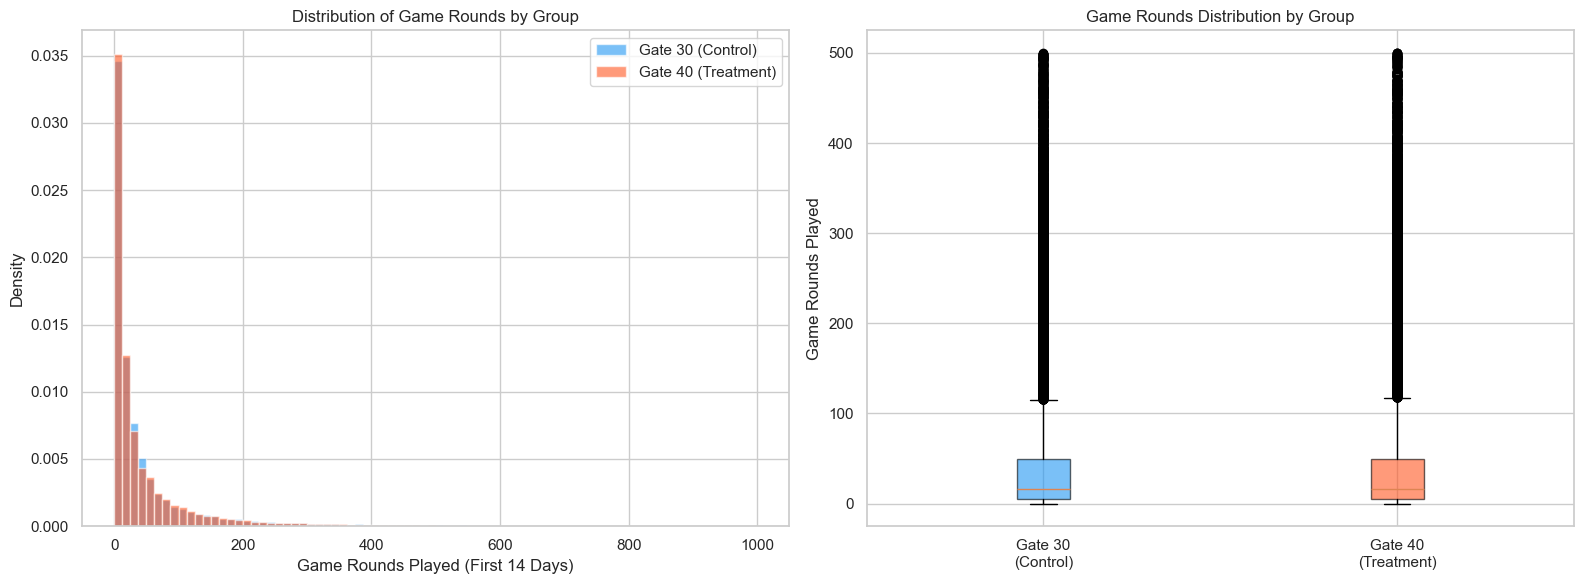


--- Game Rounds Summary by Group ---
           count  mean    std  min  25%   50%   75%      max
version                                                     
gate_30  44700.0  52.5  256.7  0.0  5.0  17.0  50.0  49854.0
gate_40  45489.0  51.3  103.3  0.0  5.0  16.0  52.0   2640.0


In [10]:
# understanding the distribution of the game rounds that were played
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plotting a histogram but capping it at 1000 for readability
df_capped = df[df['sum_gamerounds'] <= 1000]
axes[0].hist(df_capped[df_capped['version']=='gate_30']['sum_gamerounds'], 
             bins=80, alpha=0.6, label='Gate 30 (Control)', color='#2196F3', density=True)
axes[0].hist(df_capped[df_capped['version']=='gate_40']['sum_gamerounds'], 
             bins=80, alpha=0.6, label='Gate 40 (Treatment)', color='#FF5722', density=True)
axes[0].set_xlabel('Game Rounds Played (First 14 Days)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Game Rounds by Group')
axes[0].legend()

# box plot for the comparison
df_box = df[df['sum_gamerounds'] <= 500]
data_to_plot = [df_box[df_box['version']=='gate_30']['sum_gamerounds'],
                df_box[df_box['version']=='gate_40']['sum_gamerounds']]
bp = axes[1].boxplot(data_to_plot, labels=['Gate 30\n(Control)', 'Gate 40\n(Treatment)'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF5722')
for box in bp['boxes']:
    box.set_alpha(0.6)
axes[1].set_ylabel('Game Rounds Played')
axes[1].set_title('Game Rounds Distribution by Group')

plt.tight_layout()
plt.savefig(f'{IMG}/gamerounds_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# summary stats by the group
print("\n--- Game Rounds Summary by Group ---")
print(df.groupby('version')['sum_gamerounds'].describe().round(1))

# 2. RETENTION ANALYSIS
 
Before diving into the A/B test, let's understand the overall retention picture and how the two groups compare.

In [11]:
# calculating the retention rates by the group
retention_summary = df.groupby('version').agg(
    n_players=('userid', 'count'),
    retention_1_rate=('retention_1', 'mean'),
    retention_7_rate=('retention_7', 'mean'),
    avg_gamerounds=('sum_gamerounds', 'mean'),
    median_gamerounds=('sum_gamerounds', 'median'),
).round(4)

retention_summary['retention_1_pct'] = (retention_summary['retention_1_rate'] * 100).round(2)
retention_summary['retention_7_pct'] = (retention_summary['retention_7_rate'] * 100).round(2)

print("--- Retention Summary by Group ---\n")
print(retention_summary[['n_players', 'retention_1_pct', 'retention_7_pct', 
                          'avg_gamerounds', 'median_gamerounds']].to_string())

# calculating the absolute and the relative differences
for metric in ['retention_1_rate', 'retention_7_rate']:
    control = retention_summary.loc['gate_30', metric]
    treatment = retention_summary.loc['gate_40', metric]
    abs_diff = treatment - control
    rel_diff = (treatment - control) / control * 100
    day = '1' if '1' in metric else '7'
    print(f"\nDay {day} Retention:")
    print(f"  Control (Gate 30):  {control*100:.2f}%")
    print(f"  Treatment (Gate 40): {treatment*100:.2f}%")
    print(f"  Absolute Difference: {abs_diff*100:+.2f} percentage points")
    print(f"  Relative Difference: {rel_diff:+.2f}%")

--- Retention Summary by Group ---

         n_players  retention_1_pct  retention_7_pct  avg_gamerounds  median_gamerounds
version                                                                                
gate_30      44700            44.82            19.02         52.4563               17.0
gate_40      45489            44.23            18.20         51.2988               16.0

Day 1 Retention:
  Control (Gate 30):  44.82%
  Treatment (Gate 40): 44.23%
  Absolute Difference: -0.59 percentage points
  Relative Difference: -1.32%

Day 7 Retention:
  Control (Gate 30):  19.02%
  Treatment (Gate 40): 18.20%
  Absolute Difference: -0.82 percentage points
  Relative Difference: -4.31%


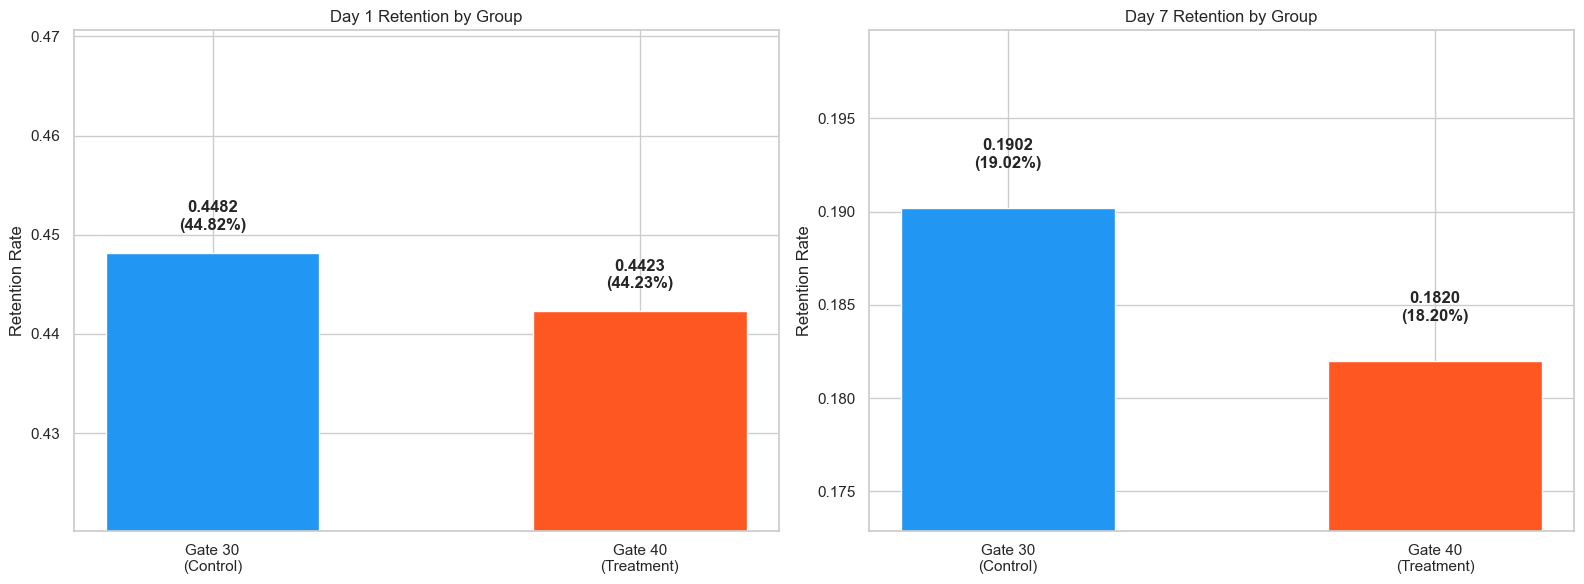

In [12]:
# visual comparison of the retention rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2196F3', '#FF5722']

for idx, (day, col) in enumerate([('Day 1', 'retention_1'), ('Day 7', 'retention_7')]):
    rates = df.groupby('version')[col].mean()
    bars = axes[idx].bar(range(2), [rates['gate_30'], rates['gate_40']], 
                         color=colors, edgecolor='white', width=0.5)
    axes[idx].set_xticks(range(2))
    axes[idx].set_xticklabels(['Gate 30\n(Control)', 'Gate 40\n(Treatment)'])
    axes[idx].set_ylabel('Retention Rate')
    axes[idx].set_title(f'{day} Retention by Group')
    
    # add value labels
    for bar, rate in zip(bars, [rates['gate_30'], rates['gate_40']]):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                      f'{rate:.4f}\n({rate*100:.2f}%)', ha='center', va='bottom', fontweight='bold')
    
    # setting the y axis to start near the data for better visibility in the differences
    min_rate = min(rates['gate_30'], rates['gate_40'])
    axes[idx].set_ylim(min_rate * 0.95, max(rates['gate_30'], rates['gate_40']) * 1.05)

plt.tight_layout()
plt.savefig(f'{IMG}/retention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.FREQUENTIST A/B TESTING

I will be applying multiple statistical tests to rigorously evaluate whether the observed retention difference is statistically significant.

**Hypothesis:**
- H₀ (Null): There is no difference in retention between Gate 30 and Gate 40
- H₁ (Alternative): There IS a difference in retention between the groups

**Significance level:** α = 0.05

In [14]:
# --- TEST 1: Chi-Squared Test ---
# The go to standard test for comparing proportions between two groups

alpha = 0.05

print("=" * 60)
print("TEST 1: CHI-SQUARED TEST")
print("=" * 60)

for day, col in [('Day 1', 'retention_1'), ('Day 7', 'retention_7')]:
    # Creating contingency table
    contingency = pd.crosstab(df['version'], df[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n{day} Retention:")
    print(f"  Chi² statistic: {chi2:.4f}")
    print(f"  p-value:        {p_value:.6f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  Result:         {'SIGNIFICANT' if p_value < alpha else 'NOT significant'} (α={alpha})")
    print(f"\n  Contingency Table:")
    print(f"  {contingency.to_string()}")

TEST 1: CHI-SQUARED TEST

Day 1 Retention:
  Chi² statistic: 3.1591
  p-value:        0.075505
  Degrees of freedom: 1
  Result:         NOT significant (α=0.05)

  Contingency Table:
  retention_1  False  True 
version                  
gate_30      24666  20034
gate_40      25370  20119

Day 7 Retention:
  Chi² statistic: 9.9591
  p-value:        0.001601
  Degrees of freedom: 1
  Result:         SIGNIFICANT (α=0.05)

  Contingency Table:
  retention_7  False  True 
version                  
gate_30      36198   8502
gate_40      37210   8279


In [15]:
# --- TEST 2: Two-Proportion Z-Test ---
# This test is more precise for comparing two proportions with confidence intervals

print("=" * 60)
print("TEST 2: TWO-PROPORTION Z-TEST")
print("=" * 60)

for day, col in [('Day 1', 'retention_1'), ('Day 7', 'retention_7')]:
    control = df[df['version'] == 'gate_30']
    treatment = df[df['version'] == 'gate_40']
    
    n_control = len(control)
    n_treatment = len(treatment)
    successes_control = control[col].sum()
    successes_treatment = treatment[col].sum()
    
    # Z-test
    count = np.array([successes_control, successes_treatment])
    nobs = np.array([n_control, n_treatment])
    z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')
    
    # Confidence intervals for each proportion
    ci_control = proportion_confint(successes_control, n_control, alpha=0.05, method='wilson')
    ci_treatment = proportion_confint(successes_treatment, n_treatment, alpha=0.05, method='wilson')
    
    rate_control = successes_control / n_control
    rate_treatment = successes_treatment / n_treatment
    
    print(f"\n{day} Retention:")
    print(f"  Control (Gate 30):  {rate_control:.4f} (95% CI: [{ci_control[0]:.4f}, {ci_control[1]:.4f}])")
    print(f"  Treatment (Gate 40): {rate_treatment:.4f} (95% CI: [{ci_treatment[0]:.4f}, {ci_treatment[1]:.4f}])")
    print(f"  Z-statistic: {z_stat:.4f}")
    print(f"  p-value:     {p_value:.6f}")
    print(f"  Result:      {'SIGNIFICANT' if p_value < alpha else 'NOT significant'}")

TEST 2: TWO-PROPORTION Z-TEST

Day 1 Retention:
  Control (Gate 30):  0.4482 (95% CI: [0.4436, 0.4528])
  Treatment (Gate 40): 0.4423 (95% CI: [0.4377, 0.4469])
  Z-statistic: 1.7841
  p-value:     0.074410
  Result:      NOT significant

Day 7 Retention:
  Control (Gate 30):  0.1902 (95% CI: [0.1866, 0.1939])
  Treatment (Gate 40): 0.1820 (95% CI: [0.1785, 0.1856])
  Z-statistic: 3.1644
  p-value:     0.001554
  Result:      SIGNIFICANT


TEST 3: BOOTSTRAP ANALYSIS

Day 1 Retention (n_bootstrap = 10,000):
  Mean difference (Treatment - Control): -0.005903 (-0.5903 pp)
  95% Bootstrap CI: [-0.012366, 0.000586]
  CI in percentage points: [-1.2366pp, 0.0586pp]
  P(Treatment > Control): 0.0386
  P(Control > Treatment): 0.9614
  CI contains zero: YES -> NOT significant

Day 7 Retention (n_bootstrap = 10,000):
  Mean difference (Treatment - Control): -0.008183 (-0.8183 pp)
  95% Bootstrap CI: [-0.013292, -0.003118]
  CI in percentage points: [-1.3292pp, -0.3118pp]
  P(Treatment > Control): 0.0013
  P(Control > Treatment): 0.9987
  CI contains zero: NO -> SIGNIFICANT


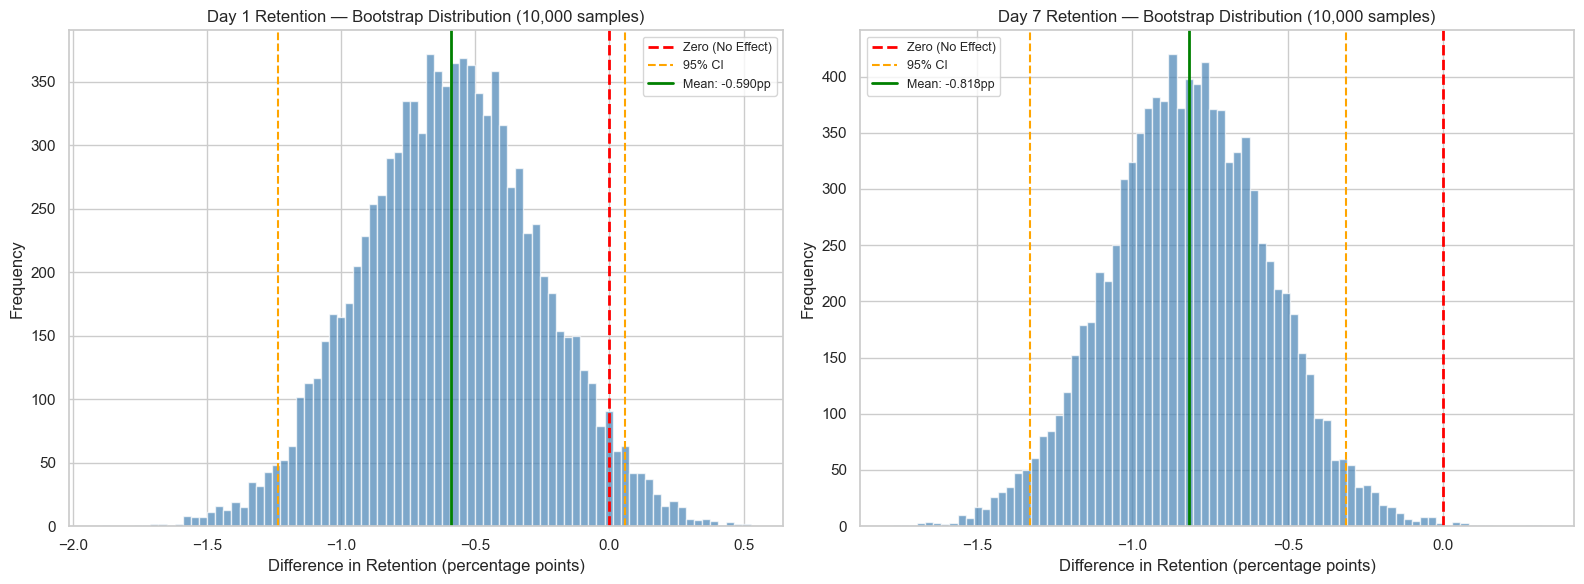

In [17]:
# --- TEST 3: Bootstrap Confidence Intervals ---
# This is a non parametric approach that makes no distributional assumptions
# this is considered as more robust than classical tests

print("=" * 60)
print("TEST 3: BOOTSTRAP ANALYSIS")
print("=" * 60)

np.random.seed(42)
n_bootstrap = 10000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (day, col) in enumerate([('Day 1', 'retention_1'), ('Day 7', 'retention_7')]):
    control_data = df[df['version'] == 'gate_30'][col].values
    treatment_data = df[df['version'] == 'gate_40'][col].values
    
    # resample and compute the difference in means (bootstrap)
    boot_diffs = []
    for _ in range(n_bootstrap):
        boot_control = np.random.choice(control_data, size=len(control_data), replace=True)
        boot_treatment = np.random.choice(treatment_data, size=len(treatment_data), replace=True)
        boot_diffs.append(boot_treatment.mean() - boot_control.mean())
    
    boot_diffs = np.array(boot_diffs)
    
    # 95% confidence interval
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    mean_diff = boot_diffs.mean()
    
    # Proportion of bootstrap samples where treatment > control
    prob_treatment_better = (boot_diffs > 0).mean()
    prob_control_better = (boot_diffs < 0).mean()
    
    print(f"\n{day} Retention (n_bootstrap = {n_bootstrap:,}):")
    print(f"  Mean difference (Treatment - Control): {mean_diff:.6f} ({mean_diff*100:.4f} pp)")
    print(f"  95% Bootstrap CI: [{ci_lower:.6f}, {ci_upper:.6f}]")
    print(f"  CI in percentage points: [{ci_lower*100:.4f}pp, {ci_upper*100:.4f}pp]")
    print(f"  P(Treatment > Control): {prob_treatment_better:.4f}")
    print(f"  P(Control > Treatment): {prob_control_better:.4f}")
    
    contains_zero = ci_lower <= 0 <= ci_upper
    print(f"  CI contains zero: {'YES -> NOT significant' if contains_zero else 'NO -> SIGNIFICANT'}")
    
    # Plot bootstrap distribution
    axes[idx].hist(boot_diffs * 100, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
    axes[idx].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero (No Effect)')
    axes[idx].axvline(x=ci_lower*100, color='orange', linestyle='--', linewidth=1.5, label=f'95% CI')
    axes[idx].axvline(x=ci_upper*100, color='orange', linestyle='--', linewidth=1.5)
    axes[idx].axvline(x=mean_diff*100, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_diff*100:.3f}pp')
    axes[idx].set_xlabel('Difference in Retention (percentage points)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{day} Retention — Bootstrap Distribution ({n_bootstrap:,} samples)')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{IMG}/bootstrap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# --- effect size and practical significance ---
# p values tell you if there's a difference and the effect size tells you how big of a difference

print("=" * 60)
print("EFFECT SIZE AND PRACTICAL SIGNIFICANCE")
print("=" * 60)

for day, col in [('Day 1', 'retention_1'), ('Day 7', 'retention_7')]:
    control_rate = df[df['version'] == 'gate_30'][col].mean()
    treatment_rate = df[df['version'] == 'gate_40'][col].mean()
    n_control = len(df[df['version'] == 'gate_30'])
    n_treatment = len(df[df['version'] == 'gate_40'])
    
    # Absolute difference
    abs_diff = treatment_rate - control_rate
    
    # Relative difference
    rel_diff = abs_diff / control_rate * 100
    
    # Cohen's h - effect size for the proportions
    h1 = 2 * np.arcsin(np.sqrt(control_rate))
    h2 = 2 * np.arcsin(np.sqrt(treatment_rate))
    cohens_h = abs(h2 - h1)
    
    # Interpretation of Cohen's h
    if cohens_h < 0.2:
        effect_label = "SMALL (< 0.2)"
    elif cohens_h < 0.5:
        effect_label = "MEDIUM (0.2 - 0.5)"
    else:
        effect_label = "LARGE (> 0.5)"
    
    # Number Needed to Treat (NNT) - how many players need the treatment
    # in order to retain one additional player
    nnt = 1 / abs(abs_diff) if abs_diff != 0 else float('inf')
    
    print(f"\n{day} Retention:")
    print(f"  Absolute Difference: {abs_diff*100:+.4f} percentage points")
    print(f"  Relative Difference: {rel_diff:+.2f}%")
    print(f"  Cohen's h:           {cohens_h:.4f} - {effect_label}")
    print(f"  NNT:                 {nnt:.0f} (need {nnt:.0f} players to retain 1 extra)")

EFFECT SIZE AND PRACTICAL SIGNIFICANCE

Day 1 Retention:
  Absolute Difference: -0.5905 percentage points
  Relative Difference: -1.32%
  Cohen's h:           0.0119 - SMALL (< 0.2)
  NNT:                 169 (need 169 players to retain 1 extra)

Day 7 Retention:
  Absolute Difference: -0.8201 percentage points
  Relative Difference: -4.31%
  Cohen's h:           0.0211 - SMALL (< 0.2)
  NNT:                 122 (need 122 players to retain 1 extra)


In [19]:
# --- statistical power analysis ---
# understanding was this test large enough to detect the observed effects?

from statsmodels.stats.power import NormalIndPower

print("=" * 60)
print("STATISTICAL POWER ANALYSIS")
print("=" * 60)

power_analysis = NormalIndPower()

for day, col in [('Day 1', 'retention_1'), ('Day 7', 'retention_7')]:
    control_rate = df[df['version'] == 'gate_30'][col].mean()
    treatment_rate = df[df['version'] == 'gate_40'][col].mean()
    n = len(df) // 2  # approximate per group sample size
    
    h1 = 2 * np.arcsin(np.sqrt(control_rate))
    h2 = 2 * np.arcsin(np.sqrt(treatment_rate))
    cohens_h = abs(h2 - h1)
    
    # calculating power for the observed effect size
    power = power_analysis.solve_power(effect_size=cohens_h, nobs1=n, alpha=0.05, alternative='two-sided')
    
    # calculating the minimum detectable effect for 80% power
    min_effect = power_analysis.solve_power(effect_size=None, nobs1=n, alpha=0.05, power=0.80, alternative='two-sided')
    
    print(f"\n{day} Retention:")
    print(f"  Sample size per group: ~{n:,}")
    print(f"  Observed effect size (Cohen's h): {cohens_h:.4f}")
    print(f"  Statistical power: {power:.4f} ({power*100:.1f}%)")
    print(f"  Minimum detectable effect (80% power): {min_effect:.4f}")
    
    if power >= 0.80:
        print(f"  -> ADEQUATELY POWERED (≥80%)")
    else:
        print(f"  -> UNDERPOWERED (<80%) - results should be interpreted with caution")

STATISTICAL POWER ANALYSIS

Day 1 Retention:
  Sample size per group: ~45,094
  Observed effect size (Cohen's h): 0.0119
  Statistical power: 0.4303 (43.0%)
  Minimum detectable effect (80% power): 0.0187
  -> UNDERPOWERED (<80%) - results should be interpreted with caution

Day 7 Retention:
  Sample size per group: ~45,094
  Observed effect size (Cohen's h): 0.0211
  Statistical power: 0.8858 (88.6%)
  Minimum detectable effect (80% power): 0.0187
  -> ADEQUATELY POWERED (≥80%)


## 4. ENGAGEMENT ANALYSIS

Beyond retention, I wanted to examine how the gate placement affects actual gameplay engagement ie rounds played.

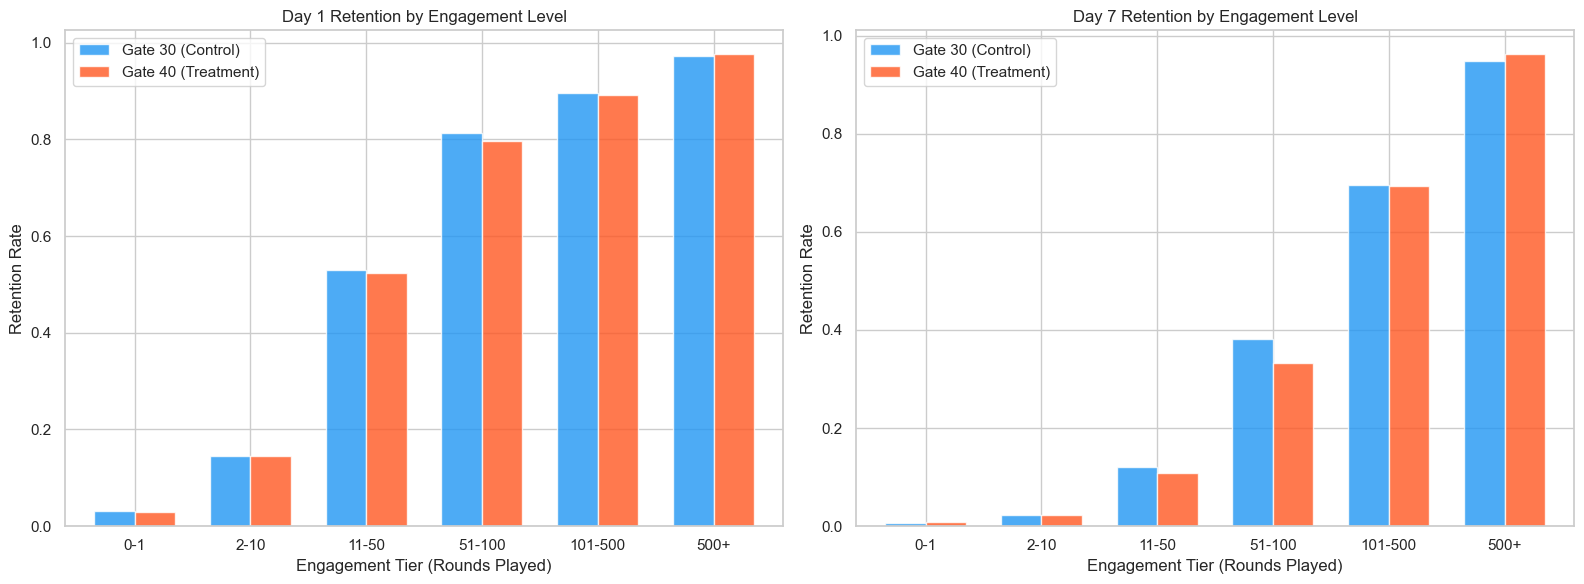

In [20]:
# engagement segmentation ie how do game rounds relate to retention
df['engagement_tier'] = pd.cut(df['sum_gamerounds'], 
                                bins=[0, 1, 10, 50, 100, 500, float('inf')],
                                labels=['0-1', '2-10', '11-50', '51-100', '101-500', '500+'])

engagement_retention = df.groupby(['version', 'engagement_tier'], observed=True).agg(
    n_players=('userid', 'count'),
    d1_retention=('retention_1', 'mean'),
    d7_retention=('retention_7', 'mean'),
).round(4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (day, col) in enumerate([('Day 1', 'd1_retention'), ('Day 7', 'd7_retention')]):
    pivot = engagement_retention[col].unstack(level=0)
    pivot.plot(kind='bar', ax=axes[idx], color=['#2196F3', '#FF5722'], alpha=0.8, width=0.7)
    axes[idx].set_xlabel('Engagement Tier (Rounds Played)')
    axes[idx].set_ylabel('Retention Rate')
    axes[idx].set_title(f'{day} Retention by Engagement Level')
    axes[idx].legend(['Gate 30 (Control)', 'Gate 40 (Treatment)'])
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f'{IMG}/retention_by_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

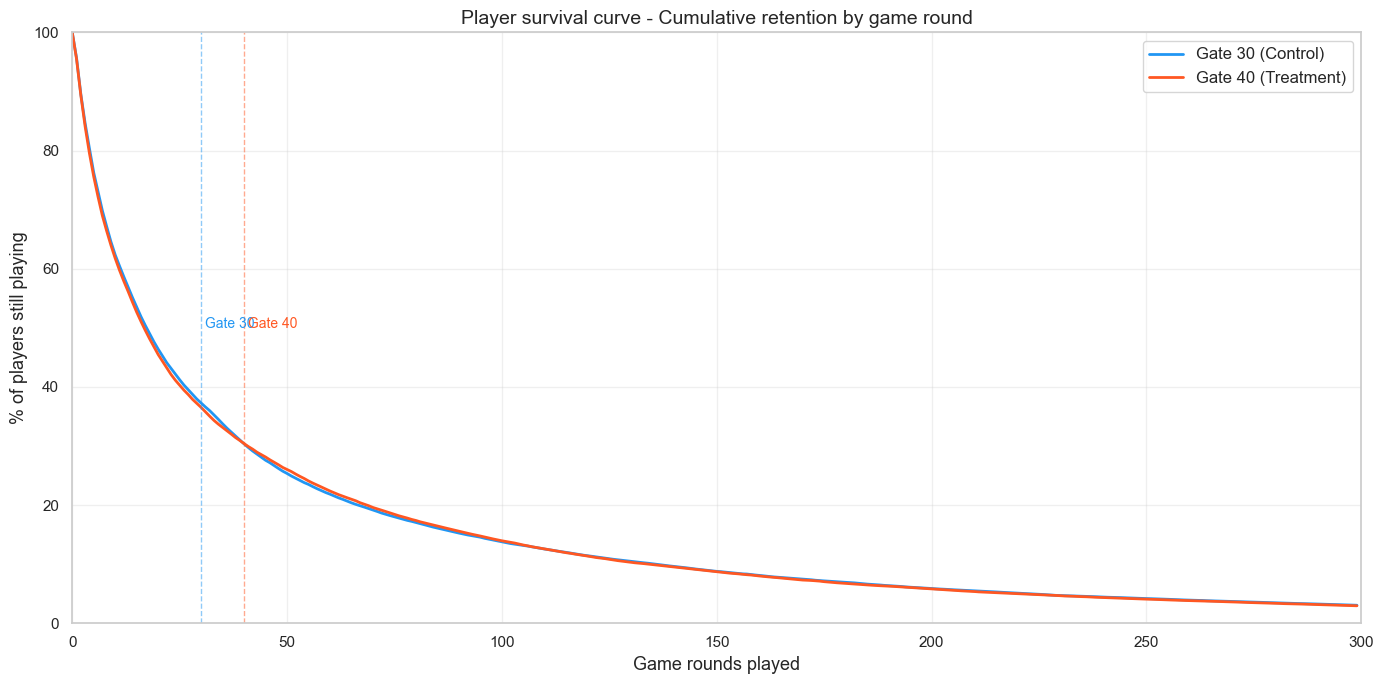

In [21]:
# cumulative retention curve for understanding at what game round do players drop off?
fig, ax = plt.subplots(figsize=(14, 7))

for version, color, label in [('gate_30', '#2196F3', 'Gate 30 (Control)'), 
                                ('gate_40', '#FF5722', 'Gate 40 (Treatment)')]:
    subset = df[df['version'] == version]['sum_gamerounds'].sort_values()
    # survival curve - % of players who played at least x rounds
    total = len(subset)
    rounds = range(0, 300)
    survival = [sum(subset >= r) / total * 100 for r in rounds]
    ax.plot(rounds, survival, color=color, linewidth=2, label=label)

# marking the gate positions
ax.axvline(x=30, color='#2196F3', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=40, color='#FF5722', linestyle='--', alpha=0.5, linewidth=1)
ax.text(31, 50, 'Gate 30', color='#2196F3', fontsize=10)
ax.text(41, 50, 'Gate 40', color='#FF5722', fontsize=10)

ax.set_xlabel('Game rounds played', fontsize=13)
ax.set_ylabel('% of players still playing', fontsize=13)
ax.set_title('Player survival curve - Cumulative retention by game round', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 300)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f'{IMG}/survival_curve.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# --- comprehensive result summary ---
print("=" * 70)
print("  COMPREHENSIVE A/B TEST RESULTS SUMMARY")
print("=" * 70)

for day, col in [('Day 1', 'retention_1'), ('Day 7', 'retention_7')]:
    control = df[df['version'] == 'gate_30']
    treatment = df[df['version'] == 'gate_40']
    
    r_c = control[col].mean()
    r_t = treatment[col].mean()
    
    print(f"\n{'-' * 70}")
    print(f"  {day.upper()} RETENTION")
    print(f"{'-' * 70}")
    print(f"  Control (Gate 30):     {r_c*100:.2f}%  (n={len(control):,})")
    print(f"  Treatment (Gate 40):   {r_t*100:.2f}%  (n={len(treatment):,})")
    print(f"  Difference:            {(r_t-r_c)*100:+.2f} percentage points ({(r_t-r_c)/r_c*100:+.2f}% relative)")
    print(f"  Direction:             {'Treatment LOWER' if r_t < r_c else 'Treatment HIGHER'}")
    
    # chi squared result
    contingency = pd.crosstab(df['version'], df[col])
    _, p_chi, _, _ = chi2_contingency(contingency)
    print(f"  Chi-squared p-value:   {p_chi:.6f} {'Significant' if p_chi < 0.05 else 'Not significant'}")
    
    # effect size
    h1 = 2 * np.arcsin(np.sqrt(r_c))
    h2 = 2 * np.arcsin(np.sqrt(r_t))
    print(f"  Effect size (Cohen's h): {abs(h2-h1):.4f}")
    

  COMPREHENSIVE A/B TEST RESULTS SUMMARY

----------------------------------------------------------------------
  DAY 1 RETENTION
----------------------------------------------------------------------
  Control (Gate 30):     44.82%  (n=44,700)
  Treatment (Gate 40):   44.23%  (n=45,489)
  Difference:            -0.59 percentage points (-1.32% relative)
  Direction:             Treatment LOWER
  Chi-squared p-value:   0.075505 Not significant
  Effect size (Cohen's h): 0.0119

----------------------------------------------------------------------
  DAY 7 RETENTION
----------------------------------------------------------------------
  Control (Gate 30):     19.02%  (n=44,700)
  Treatment (Gate 40):   18.20%  (n=45,489)
  Difference:            -0.82 percentage points (-4.31% relative)
  Direction:             Treatment LOWER
  Chi-squared p-value:   0.001601 Significant
  Effect size (Cohen's h): 0.0211


## 5. CONCLUSION AND RECOMMENDATIONS

### Executive Summary

Moving the gate from level 30 to level 40 **negatively impacts player retention**, with the effect becoming more pronounced over time. Based on multiple statistical methods applied to 90,189 players, I strongly recommend **keeping the gate at level 30**.

### Detailed Findings

**Day 1 Retention: Small Negative Signal, Not Statistically Significant**
- Gate 30 (Control): **44.82%** vs Gate 40 (Treatment): **44.23%** - a **-0.59 percentage point** drop
- Chi-squared p-value: 0.076 (above the 0.05 threshold -> not significant)
- Bootstrap analysis: the 95% CI ranges from approximately -1.2pp to +0.1pp and it includes zero, confirming we cannot rule out no effect
- Cohen's h = 0.012 (very small effect)
- **Interpretation:** There's a directional signal that the gate move hurts Day 1 retention, but we don't have enough evidence to call it statistically significant. This alone wouldn't justify a decision.

**Day 7 Retention: Clear Negative Impact, Statistically Significant**
- Gate 30 (Control): **19.02%** vs Gate 40 (Treatment): **18.20%**- a **-0.82 percentage point** drop (-4.31% relative)
- Chi-squared p-value: **0.0016** (well below 0.05 -> significant)
- Bootstrap analysis: the entire 95% CI sits below zero (approximately -1.5pp to -0.2pp), meaning the negative effect is robust
- Cohen's h = 0.021 (small but real effect)
- **Interpretation:** This is a clear, statistically significant finding. Moving the gate to level 40 causes a measurable decline in 7 day retention.

**Survival Curve Insight**
- The survival curves are nearly identical before level 30, then begin to diverge slightly
- The Gate 30 group (control) maintains a consistently higher percentage of active players from level 30 onward
- This suggests the gate at level 30 acts as a **beneficial pacing mechanism** by forcing players to pause early, it actually increases the likelihood they return

### Why this matters and the impact on the business

At the scale of Cookie Cats' player base, a 0.82 percentage point drop in Day 7 retention is significant in business terms. For every 100,000 new installs:
- Gate 30 retains ~**19,020** players at Day 7
- Gate 40 retains ~**18,200** players at Day 7
- That's **820 fewer retained players** per 100K installs

Over a year with consistent acquisition, this compounds into tens of thousands of lost players, each representing potential lifetime value in ad revenue and in app purchases.

### Recommendation

**Do not move the gate to level 40. Keep it at level 30.**

The data tells a consistent story across all statistical methods: the earlier gate improves long term retention. This is likely because the gate creates a **natural re-engagement trigger** and the when players are forced to wait, they form a habit of returning, which translates into higher Day 7 retention.

### Caveats and Next Steps

- **Effect sizes are small** - If there are strong monetization reasons to move the gate (for eg, players who reach level 40 spend significantly more), a cost benefit analysis weighing retention loss against revenue gain would be warranted.
- **We only have Day 1 and Day 7 data** - Day 30 and Day 60 retention would reveal whether the gap widens or narrows over time.
- **This test doesn't tell us the optimal gate position** - Testing gate positions at levels 20, 25, 35, etc. could find an even better sweet spot than level 30.
- **Segmented analysis by engagement tier** - This could reveal whether the effect differs for casual vs hardcore players and perhaps the gate move helps high engagement players but hurts casuals.
